**I. Nettoyage Intensif et Extraction des Données Brutes**

Cette section réalise l'extraction d'un échantillon du texte brut directement depuis les PDF. Nous appliquons un nettoyage intensif immédiat (longueur > 45 caractères et filtrage par liste noire) pour isoler les projets d'investissement.

In [7]:
import pdfplumber
import pandas as pd
import re
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# --- CONFIGURATION AUTOMATIQUE DU CHEMIN ---
base_path = Path.cwd()
if not (base_path / "data").exists():
    base_path = base_path.parent

RAW_PATH = base_path / "data" / "raw"

def nettoyage_intensif_pdf(nom_fichier, label):
    path = RAW_PATH / nom_fichier
    
    if not path.exists():
        print(f"[!] Fichier introuvable : {path}")
        return pd.DataFrame()

    # Liste noire (Blacklist) pour purifier le signal sémantique
    blacklist = [
        "république du cameroun", "paix - travail - patrie", "loi de finances", 
        "ministère", "page", "section", "chapitre", "alinéa", "article", 
        "total", "exercice", "budget de l'état", "stratégie nationale"
    ]
    
    articles_propres = []
    print(f"[#] Extraction et nettoyage intensif de : {nom_fichier}...")
    
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                for line in text.split('\n'):
                    line_strip = line.strip()
                    
                    # Filtres de qualité
                    if len(line_strip) < 45:
                        continue
                    
                    line_lower = line_strip.lower()
                    if any(mot in line_lower for mot in blacklist):
                        continue
                    
                    if re.match(r'^[0-9\s\.,]+$', line_strip):
                        continue
                    
                    articles_propres.append({
                        "Source": label,
                        "Contenu_Nettoyé": " ".join(line_strip.split())
                    })
    
    df = pd.DataFrame(articles_propres).drop_duplicates(subset=['Contenu_Nettoyé'])
    return df

# --- EXÉCUTION DE L'EXTRACTION ---
df_24 = nettoyage_intensif_pdf("Loi_de_Finances_2024.pdf", "2024")
df_25 = nettoyage_intensif_pdf("Loi_de_Finances_2025.pdf", "2025")
df_snd30 = nettoyage_intensif_pdf("SND30_Document.pdf", "SND30")

print(f"\n[RÉSULTAT] 2024  : {len(df_24)} articles")
print(f"[RÉSULTAT] 2025  : {len(df_25)} articles")
print(f"[RÉSULTAT] SND30 : {len(df_snd30)} articles")

[#] Extraction et nettoyage intensif de : Loi_de_Finances_2024.pdf...
[#] Extraction et nettoyage intensif de : Loi_de_Finances_2025.pdf...
[#] Extraction et nettoyage intensif de : SND30_Document.pdf...

[RÉSULTAT] 2024  : 2198 articles
[RÉSULTAT] 2025  : 1956 articles
[RÉSULTAT] SND30 : 1507 articles


**II. Visualisation de la Distribution des Longueurs**

L'analyse de la longueur des articles après nettoyage intensif permet de vérifier la similarité structurelle des deux exercices budgétaires. Un décalage trop important indiquerait une erreur d'extraction ou une modification de la structure du PDF.

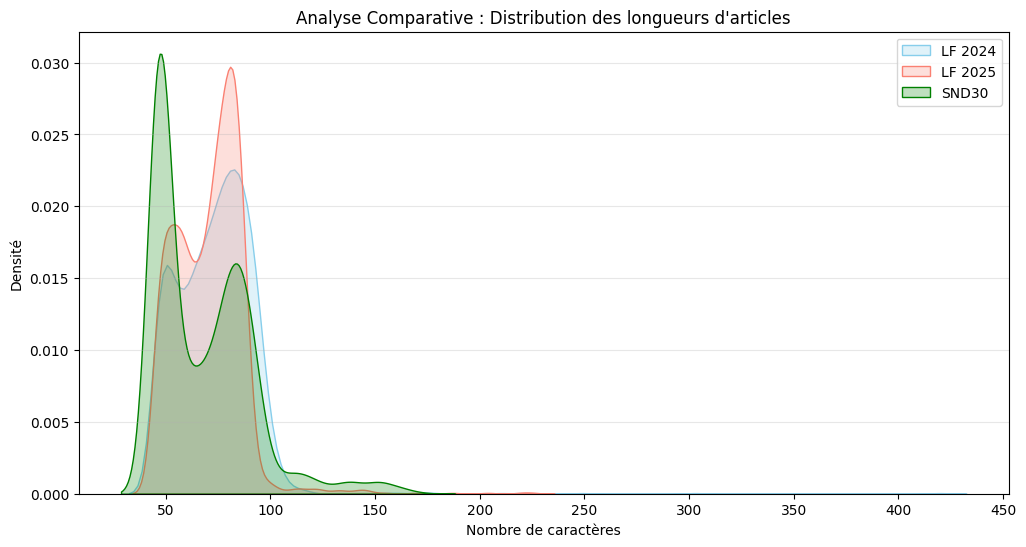

In [8]:
plt.figure(figsize=(12, 6))

datasets = [
    (df_24, "LF 2024", "skyblue"),
    (df_25, "LF 2025", "salmon"),
    (df_snd30, "SND30", "green")
]

for df, label, color in datasets:
    if not df.empty:
        sns.kdeplot(df['Contenu_Nettoyé'].str.len(), label=label, fill=True, color=color)

plt.title("Analyse Comparative : Distribution des longueurs d'articles")
plt.xlabel("Nombre de caractères")
plt.ylabel("Densité")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

**III. Nuage de Mots**

Cette visualisation finale permet de valider la cohérence thématique. Les Lois de Finances doivent faire ressortir des termes opérationnels, tandis que la SND30 doit mettre en avant les piliers de la transformation structurelle (industrie, capital humain, gouvernance)

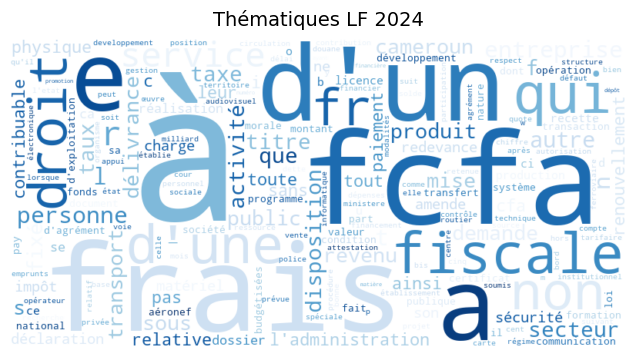

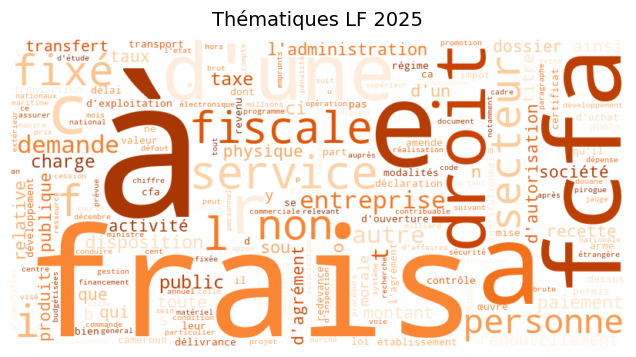

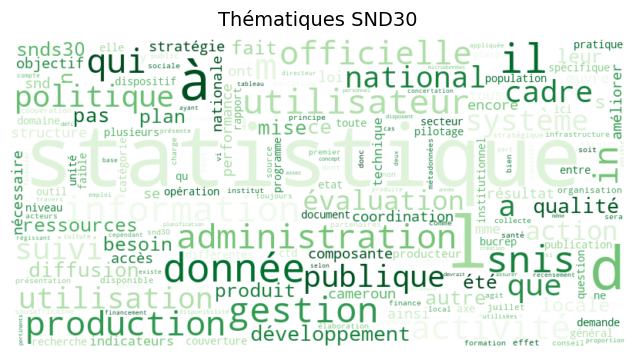

In [9]:
def generer_nuage_comparatif(df, titre, color_map):
    if df.empty: return
    
    # Stopwords français et résidus techniques
    mots_vides = {
        'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en', 'au', 'aux', 
        'pour', 'sur', 'dans', 'est', 'sont', 'cette', 'ces', 'par', 'ou', 'avec',
        'plus', 'être', 'avoir', 'pour', 'dans', 'dans', 'the', 'and', 'with'
    }
    
    texte = " ".join(df['Contenu_Nettoyé'].tolist()).lower()
    
    wc = WordCloud(
        width=800, height=400, 
        background_color='white',
        stopwords=mots_vides,
        colormap=color_map,
        collocations=False
    ).generate(texte)

    plt.figure(figsize=(10, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(titre, fontsize=14, pad=10)
    plt.axis('off')
    plt.show()

# Affichage
generer_nuage_comparatif(df_24, "Thématiques LF 2024", "Blues")
generer_nuage_comparatif(df_25, "Thématiques LF 2025", "Oranges")
generer_nuage_comparatif(df_snd30, "Thématiques SND30", "Greens")

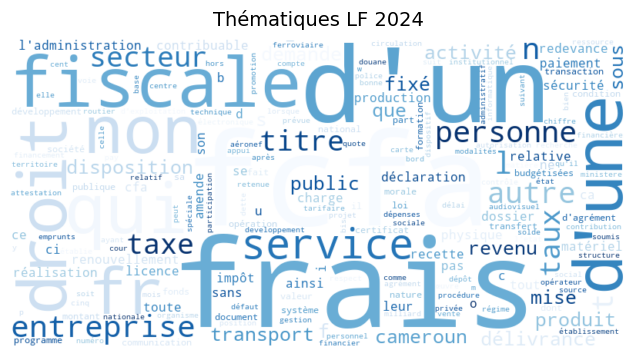

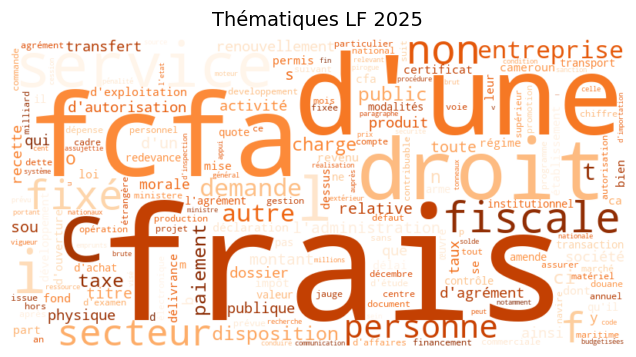

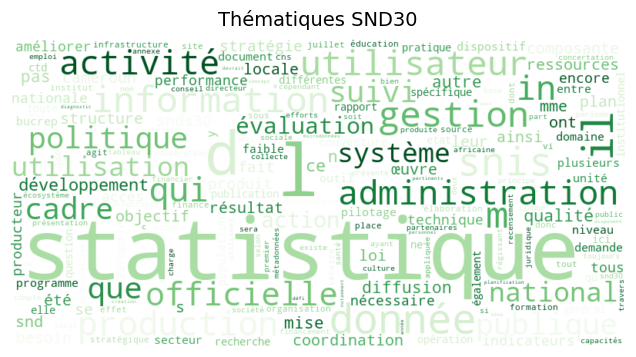

In [12]:
def generer_nuage_comparatif(df, titre, color_map):
    if df.empty: return
    
    # Stopwords français et résidus techniques
    mots_vides = {
        'le', 'la', 'les', 'de', 'du', 'des', 'a', 'r', 'e','à','un', 'une', 'et', 'en', 'au', 'aux', 
        'pour', 'sur', 'dans', 'est', 'sont', 'cette', 'ces', 'par', 'ou', 'avec',
        'plus', 'être', 'avoir', 'pour', 'dans', 'dans', 'the', 'and', 'with'
    }
    
    texte = " ".join(df['Contenu_Nettoyé'].tolist()).lower()
    
    wc = WordCloud(
        width=800, height=400, 
        background_color='white',
        stopwords=mots_vides,
        colormap=color_map,
        collocations=False
    ).generate(texte)

    plt.figure(figsize=(10, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(titre, fontsize=14, pad=10)
    plt.axis('off')
    plt.show()

# Affichage
generer_nuage_comparatif(df_24, "Thématiques LF 2024", "Blues")
generer_nuage_comparatif(df_25, "Thématiques LF 2025", "Oranges")
generer_nuage_comparatif(df_snd30, "Thématiques SND30", "Greens")